# Evaluación del Sistema RAG

Este notebook evalúa el sistema RAG (Retrieval-Augmented Generation) del agente periodístico.

## Métricas a evaluar:

### Retrieval (Recuperación)
- **Precision@K**: De los K documentos recuperados, ¿cuántos son relevantes?
- **Hit Rate**: ¿Al menos un documento es relevante?
- **MRR (Mean Reciprocal Rank)**: ¿En qué posición está el primer resultado relevante?

### Generation (Generación)
- **Faithfulness**: ¿La respuesta está basada en los documentos? (no alucina)
- **Answer Relevancy**: ¿La respuesta es relevante a la pregunta?
- **Citation Accuracy**: ¿Las citas [1], [2] son correctas?

In [1]:
# Imports
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from typing import Optional

# Nuestros módulos
from src.storage.database import get_db
from src.storage.repositories.article import ArticleRepository
from src.rag.engine import RAGEngine
from src.processing.embeddings import get_embedding_generator
from src.llm.factory import get_available_client

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 100)

print("✓ Imports completados")

✓ Imports completados


## 1. Estado de la Base de Datos

In [2]:
# Verificar estado de la DB
from sqlalchemy import func
from src.storage.models import Article, ProcessedArticle, AgentSession

with get_db() as db:
    total_articles = db.query(func.count(Article.id)).scalar()
    with_embeddings = db.query(func.count(Article.id)).filter(Article.embedding.isnot(None)).scalar()
    processed = db.query(func.count(ProcessedArticle.id)).scalar()
    sessions = db.query(func.count(AgentSession.id)).scalar()
    
    # Por categoría
    categories = db.query(
        Article.category,
        func.count(Article.id)
    ).group_by(Article.category).all()

print("=" * 50)
print("ESTADO DE LA BASE DE DATOS")
print("=" * 50)
print(f"Total artículos:        {total_articles}")
print(f"Con embeddings:         {with_embeddings}")
print(f"Procesados (resumen):   {processed}")
print(f"Sesiones del agente:    {sessions}")
print()
print("Por categoría:")
for cat, count in sorted(categories, key=lambda x: x[1], reverse=True):
    print(f"  {cat or 'Sin categoría'}: {count}")

ESTADO DE LA BASE DE DATOS
Total artículos:        1688
Con embeddings:         1688
Procesados (resumen):   48
Sesiones del agente:    23

Por categoría:
  sports: 295
  science: 271
  general: 264
  technology: 252
  health: 244
  business: 174
  entertainment: 78
  Sin categoría: 46
  world: 34
  nation: 24
  politics: 4
  Otras Ciudades: 1
  Medellín: 1


## 2. Dataset de Evaluación

Creamos un conjunto de preguntas de prueba para evaluar el sistema.

In [3]:
# Dataset de evaluación AMPLIADO
# 25 preguntas cubriendo diferentes categorías y niveles de especificidad

EVALUATION_QUESTIONS = [
    # === ECONOMÍA / BUSINESS (6 preguntas) ===
    {
        "question": "¿Qué está pasando con la economía?",
        "category": "business",
        "expected_topics": ["economía", "PIB", "inflación", "mercado"],
    },
    {
        "question": "¿Cuáles son las perspectivas económicas para 2026?",
        "category": "business",
        "expected_topics": ["economía", "crecimiento", "proyección", "2026"],
    },
    {
        "question": "¿Cómo está la inflación actualmente?",
        "category": "business",
        "expected_topics": ["inflación", "precios", "aumento", "porcentaje"],
    },
    {
        "question": "¿Qué está pasando con los salarios?",
        "category": "business",
        "expected_topics": ["salario", "aumento", "trabajador", "empresa"],
    },
    {
        "question": "¿Hay noticias sobre inversiones?",
        "category": "business",
        "expected_topics": ["inversión", "capital", "mercado", "fondo"],
    },
    {
        "question": "¿Qué dicen los analistas económicos?",
        "category": "business",
        "expected_topics": ["analista", "economía", "expectativa", "pronóstico"],
    },
    
    # === TECNOLOGÍA (5 preguntas) ===
    {
        "question": "¿Cuáles son las últimas noticias de tecnología?",
        "category": "technology",
        "expected_topics": ["tecnología", "inteligencia artificial", "software", "apps"],
    },
    {
        "question": "¿Qué avances hay en inteligencia artificial?",
        "category": "technology",
        "expected_topics": ["inteligencia artificial", "IA", "modelo", "aprendizaje"],
    },
    {
        "question": "¿Hay noticias sobre redes sociales?",
        "category": "technology",
        "expected_topics": ["red social", "usuario", "plataforma", "app"],
    },
    {
        "question": "¿Qué está pasando con las empresas tecnológicas?",
        "category": "technology",
        "expected_topics": ["empresa", "tecnología", "startup", "innovación"],
    },
    {
        "question": "¿Hay noticias sobre ciberseguridad?",
        "category": "technology",
        "expected_topics": ["seguridad", "hacker", "datos", "protección"],
    },
    
    # === SALUD (4 preguntas) ===
    {
        "question": "¿Qué noticias hay sobre salud?",
        "category": "health",
        "expected_topics": ["salud", "medicina", "hospital", "enfermedad"],
    },
    {
        "question": "¿Hay noticias sobre vacunas?",
        "category": "health",
        "expected_topics": ["vacuna", "inmunización", "dosis", "campaña"],
    },
    {
        "question": "¿Qué dicen los expertos sobre salud mental?",
        "category": "health",
        "expected_topics": ["salud mental", "depresión", "ansiedad", "bienestar"],
    },
    {
        "question": "¿Hay avances médicos recientes?",
        "category": "health",
        "expected_topics": ["médico", "tratamiento", "estudio", "investigación"],
    },
    
    # === DEPORTES (4 preguntas) ===
    {
        "question": "¿Qué está pasando en el mundo del deporte?",
        "category": "sports",
        "expected_topics": ["deporte", "fútbol", "jugador", "equipo"],
    },
    {
        "question": "¿Cuáles son los resultados deportivos recientes?",
        "category": "sports",
        "expected_topics": ["resultado", "partido", "victoria", "derrota"],
    },
    {
        "question": "¿Hay noticias de fútbol?",
        "category": "sports",
        "expected_topics": ["fútbol", "gol", "equipo", "liga"],
    },
    {
        "question": "¿Qué fichajes o traspasos hay en el fútbol?",
        "category": "sports",
        "expected_topics": ["fichaje", "traspaso", "jugador", "club"],
    },
    
    # === CIENCIA (3 preguntas) ===
    {
        "question": "¿Hay noticias sobre ciencia?",
        "category": "science",
        "expected_topics": ["ciencia", "investigación", "estudio", "descubrimiento"],
    },
    {
        "question": "¿Qué descubrimientos científicos hay?",
        "category": "science",
        "expected_topics": ["descubrimiento", "científico", "estudio", "hallazgo"],
    },
    {
        "question": "¿Hay noticias sobre el espacio o astronomía?",
        "category": "science",
        "expected_topics": ["espacio", "NASA", "planeta", "universo"],
    },
    
    # === ENTRETENIMIENTO (2 preguntas) ===
    {
        "question": "¿Qué noticias hay de entretenimiento?",
        "category": "entertainment",
        "expected_topics": ["entretenimiento", "película", "serie", "música"],
    },
    {
        "question": "¿Hay estrenos de cine o series?",
        "category": "entertainment",
        "expected_topics": ["estreno", "película", "serie", "cine"],
    },
    
    # === MUNDO / GENERAL (1 pregunta) ===
    {
        "question": "¿Cuáles son las noticias internacionales más importantes?",
        "category": "world",
        "expected_topics": ["internacional", "país", "gobierno", "mundo"],
    },
]

print(f"Dataset de evaluación: {len(EVALUATION_QUESTIONS)} preguntas")
print("\nDistribución por categoría:")
from collections import Counter
cat_counts = Counter(q['category'] for q in EVALUATION_QUESTIONS)
for cat, count in cat_counts.most_common():
    print(f"  {cat}: {count} preguntas")

Dataset de evaluación: 25 preguntas

Distribución por categoría:
  business: 6 preguntas
  technology: 5 preguntas
  health: 4 preguntas
  sports: 4 preguntas
  science: 3 preguntas
  entertainment: 2 preguntas
  world: 1 preguntas


## 3. Métricas de Retrieval

In [4]:
def evaluate_retrieval(
    question: str,
    expected_category: str,
    k: int = 5,
    threshold: float = 0.5
) -> dict:
    """
    Evalúa la calidad del retrieval para una pregunta.
    
    Returns:
        dict con métricas de retrieval
    """
    with get_db() as db:
        engine = RAGEngine(db, use_reranking=False)
        
        # Obtener documentos recuperados
        articles = engine.get_context_only(
            question=question,
            max_sources=k,
        )
        
        if not articles:
            return {
                "question": question,
                "k": k,
                "retrieved": 0,
                "relevant": 0,
                "precision_at_k": 0.0,
                "hit_rate": 0.0,
                "mrr": 0.0,
                "avg_similarity": 0.0,
                "similarities": [],
                "categories": [],
            }
        
        # Calcular métricas
        similarities = [score for _, score in articles]
        categories = [art.category for art, _ in articles]
        
        # Un documento es "relevante" si:
        # 1. Su categoría coincide con la esperada, O
        # 2. Su similarity score es > threshold
        relevant_count = sum(
            1 for art, score in articles 
            if art.category == expected_category or score > threshold
        )
        
        # Precision@K
        precision_at_k = relevant_count / len(articles)
        
        # Hit Rate (al menos uno relevante)
        hit_rate = 1.0 if relevant_count > 0 else 0.0
        
        # MRR (Mean Reciprocal Rank)
        mrr = 0.0
        for i, (art, score) in enumerate(articles, 1):
            if art.category == expected_category or score > threshold:
                mrr = 1.0 / i
                break
        
        return {
            "question": question,
            "k": k,
            "retrieved": len(articles),
            "relevant": relevant_count,
            "precision_at_k": precision_at_k,
            "hit_rate": hit_rate,
            "mrr": mrr,
            "avg_similarity": np.mean(similarities),
            "similarities": similarities,
            "categories": categories,
        }

print("✓ Función de evaluación de retrieval definida")

✓ Función de evaluación de retrieval definida


In [5]:
# Evaluar retrieval para todas las preguntas
retrieval_results = []

for q in EVALUATION_QUESTIONS:
    print(f"Evaluando: {q['question'][:40]}...")
    result = evaluate_retrieval(
        question=q["question"],
        expected_category=q["category"],
        k=5
    )
    retrieval_results.append(result)

# Convertir a DataFrame
df_retrieval = pd.DataFrame(retrieval_results)
df_retrieval

Evaluando: ¿Qué está pasando con la economía?...
2026-02-07 18:37:49 [info     ] Using LM Studio (local)       
2026-02-07 18:37:49 [info     ] Initialized LMStudioEmbeddingGenerator base_url=http://192.168.68.54:1234/v1 model=text-embedding-nomic-embed-text-v1.5
2026-02-07 18:37:49 [info     ] RAG engine initialized         llm_available=True use_reranking=False
2026-02-07 18:37:49 [info     ] Searching for articles         limit=5 query=¿Qué está pasando con la economía? threshold=0.5
2026-02-07 18:37:49 [info     ] Search completed               results_count=5
Evaluando: ¿Cuáles son las perspectivas económicas ...
2026-02-07 18:37:49 [info     ] Using LM Studio (local)       
2026-02-07 18:37:49 [info     ] Initialized LMStudioEmbeddingGenerator base_url=http://192.168.68.54:1234/v1 model=text-embedding-nomic-embed-text-v1.5
2026-02-07 18:37:49 [info     ] RAG engine initialized         llm_available=True use_reranking=False
2026-02-07 18:37:49 [info     ] Searching for articles   

,question,k,retrieved,relevant,precision_at_k,hit_rate,mrr,avg_similarity,similarities,categories
0,¿Qué está pasando con la economía?,5,5,5,1.0,1.0,1.0,0.703291,"[0.708400710213602, 0.7076221465793159, 0.7046728690094256, 0.7031199950695121, 0.6926411047128278]","[business, business, business, business, business]"
1,¿Cuáles son las perspectivas económicas para 2026?,5,5,5,1.0,1.0,1.0,0.779847,"[0.7920783374566635, 0.7891624537594829, 0.7855018845500815, 0.7700354689507776, 0.7624575525421...","[business, business, business, technology, sports]"
2,¿Cómo está la inflación actualmente?,5,5,5,1.0,1.0,1.0,0.694293,"[0.7288017985114708, 0.7135637824839622, 0.6815833652492715, 0.6757481332041785, 0.6717672156941...","[business, business, technology, health, health]"
3,¿Qué está pasando con los salarios?,5,5,5,1.0,1.0,1.0,0.665026,"[0.6923042444068034, 0.6607639773749197, 0.6603538405263937, 0.6561797419290761, 0.6555295361351...","[business, science, sports, business, general]"
4,¿Hay noticias sobre inversiones?,5,5,5,1.0,1.0,1.0,0.649381,"[0.6646349233824295, 0.6591065336339025, 0.6435108184814499, 0.6411540271571322, 0.6384965181350...","[business, business, technology, business, sports]"
5,¿Qué dicen los analistas económicos?,5,5,5,1.0,1.0,1.0,0.716177,"[0.7561173955097227, 0.7129108740410114, 0.7097581028938496, 0.7073710524406167, 0.694725793285746]","[business, business, business, business, business]"
6,¿Cuáles son las últimas noticias de tecnología?,5,5,5,1.0,1.0,1.0,0.695031,"[0.7094207156395512, 0.6982863252501822, 0.6982863252501822, 0.6869722363708965, 0.6821910493996...","[technology, technology, technology, technology, technology]"
7,¿Qué avances hay en inteligencia artificial?,5,5,5,1.0,1.0,1.0,0.793396,"[0.8132605421608494, 0.8092758073323681, 0.7995699762913595, 0.777683698465943, 0.7671891957054537]","[business, technology, health, health, technology]"
8,¿Hay noticias sobre redes sociales?,5,5,5,1.0,1.0,1.0,0.685344,"[0.6973772797916564, 0.6858360562969457, 0.6843352898059603, 0.6824160639071587, 0.6767544948087...","[general, general, general, nation, technology]"
9,¿Qué está pasando con las empresas tecnológicas?,5,5,5,1.0,1.0,1.0,0.724724,"[0.7282612271931713, 0.7271964387414833, 0.7271964387414833, 0.72546757844711, 0.7154971957206929]","[technology, technology, technology, business, technology]"


In [6]:
# Resumen de métricas de Retrieval
print("=" * 50)
print("MÉTRICAS DE RETRIEVAL")
print("=" * 50)
print(f"Precision@5 promedio:  {df_retrieval['precision_at_k'].mean():.2%}")
print(f"Hit Rate promedio:     {df_retrieval['hit_rate'].mean():.2%}")
print(f"MRR promedio:          {df_retrieval['mrr'].mean():.3f}")
print(f"Similarity promedio:   {df_retrieval['avg_similarity'].mean():.3f}")

MÉTRICAS DE RETRIEVAL
Precision@5 promedio:  100.00%
Hit Rate promedio:     100.00%
MRR promedio:          1.000
Similarity promedio:   0.702


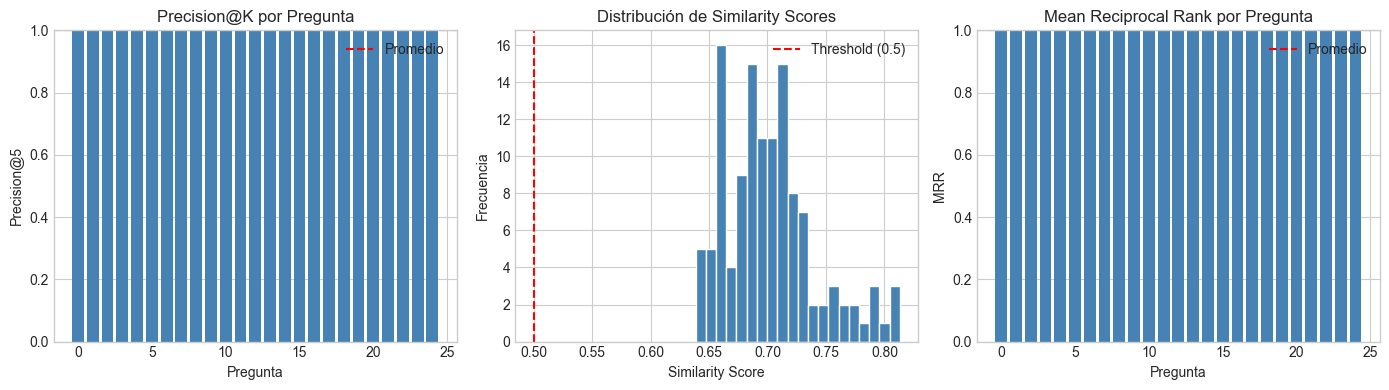

In [7]:
# Visualización de métricas de Retrieval
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Precision@K
axes[0].bar(range(len(df_retrieval)), df_retrieval['precision_at_k'], color='steelblue')
axes[0].axhline(y=df_retrieval['precision_at_k'].mean(), color='red', linestyle='--', label='Promedio')
axes[0].set_xlabel('Pregunta')
axes[0].set_ylabel('Precision@5')
axes[0].set_title('Precision@K por Pregunta')
axes[0].set_ylim(0, 1)
axes[0].legend()

# Similarity distribution
all_similarities = [s for sims in df_retrieval['similarities'] for s in sims]
axes[1].hist(all_similarities, bins=20, color='steelblue', edgecolor='white')
axes[1].axvline(x=0.5, color='red', linestyle='--', label='Threshold (0.5)')
axes[1].set_xlabel('Similarity Score')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Similarity Scores')
axes[1].legend()

# MRR
axes[2].bar(range(len(df_retrieval)), df_retrieval['mrr'], color='steelblue')
axes[2].axhline(y=df_retrieval['mrr'].mean(), color='red', linestyle='--', label='Promedio')
axes[2].set_xlabel('Pregunta')
axes[2].set_ylabel('MRR')
axes[2].set_title('Mean Reciprocal Rank por Pregunta')
axes[2].set_ylim(0, 1)
axes[2].legend()

plt.tight_layout()
plt.savefig('../docs/images/retrieval_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Métricas de Generation (RAG completo)

In [8]:
def evaluate_generation(
    question: str,
    expected_topics: list[str],
    max_sources: int = 5,
    use_reranking: bool = False,
) -> dict:
    """
    Evalúa la calidad de la generación RAG.
    
    Métricas:
    - Citation count: ¿Cuántas fuentes citó?
    - Topic coverage: ¿Menciona los temas esperados?
    - Answer length: Longitud de la respuesta
    - Confidence: Score de confianza del sistema
    """
    with get_db() as db:
        engine = RAGEngine(db, use_reranking=use_reranking)
        
        response = engine.ask(
            question=question,
            max_sources=max_sources,
        )
        
        # Contar citas en la respuesta
        import re
        citations_in_answer = len(re.findall(r'\[\d+\]', response.answer))
        
        # Verificar cobertura de temas
        answer_lower = response.answer.lower()
        topics_found = [
            topic for topic in expected_topics 
            if topic.lower() in answer_lower
        ]
        topic_coverage = len(topics_found) / len(expected_topics) if expected_topics else 0
        
        return {
            "question": question,
            "answer": response.answer,
            "sources_used": len(response.sources),
            "citations_in_answer": citations_in_answer,
            "confidence": response.confidence,
            "answer_length": len(response.answer),
            "topic_coverage": topic_coverage,
            "topics_found": topics_found,
            "use_reranking": use_reranking,
        }

print("✓ Función de evaluación de generación definida")

✓ Función de evaluación de generación definida


In [9]:
# Evaluar generación para todas las preguntas
generation_results = []

for q in EVALUATION_QUESTIONS:
    print(f"Evaluando RAG: {q['question'][:40]}...")
    result = evaluate_generation(
        question=q["question"],
        expected_topics=q["expected_topics"],
        max_sources=5,
        use_reranking=False,
    )
    generation_results.append(result)

# Convertir a DataFrame
df_generation = pd.DataFrame(generation_results)
df_generation[['question', 'sources_used', 'citations_in_answer', 'confidence', 'topic_coverage']]

Evaluando RAG: ¿Qué está pasando con la economía?...
2026-02-07 18:37:58 [info     ] Using LM Studio (local)       
2026-02-07 18:37:58 [info     ] Initialized LMStudioEmbeddingGenerator base_url=http://192.168.68.54:1234/v1 model=text-embedding-nomic-embed-text-v1.5
2026-02-07 18:37:58 [info     ] RAG engine initialized         llm_available=True use_reranking=False
2026-02-07 18:37:58 [info     ] Processing RAG query           category=None max_sources=5 question=¿Qué está pasando con la economía?
2026-02-07 18:37:58 [info     ] Searching for articles         limit=5 query=¿Qué está pasando con la economía? threshold=0.5
2026-02-07 18:37:58 [info     ] Search completed               results_count=5
2026-02-07 18:37:58 [info     ] Generating RAG response        articles=5 query=¿Qué está pasando con la economía?
2026-02-07 18:38:27 [info     ] RAG response generated         answer_length=1435 confidence=0.861276190124162 sources_used=3
2026-02-07 18:38:27 [info     ] RAG query complet

,question,sources_used,citations_in_answer,confidence,topic_coverage
0,¿Qué está pasando con la economía?,3,3,0.861276,0.25
1,¿Cuáles son las perspectivas económicas para 2026?,3,3,0.877783,0.50
2,¿Cómo está la inflación actualmente?,2,2,0.824237,0.75
3,¿Qué está pasando con los salarios?,1,1,0.678461,0.75
4,¿Hay noticias sobre inversiones?,3,3,0.851150,0.25
5,¿Qué dicen los analistas económicos?,3,3,0.865252,0.75
6,¿Cuáles son las últimas noticias de tecnología?,5,5,0.939006,0.50
7,¿Qué avances hay en inteligencia artificial?,5,5,0.958679,1.00
8,¿Hay noticias sobre redes sociales?,5,5,0.937069,0.50
9,¿Qué está pasando con las empresas tecnológicas?,3,3,0.865510,0.75


In [10]:
# Resumen de métricas de Generación
print("=" * 50)
print("MÉTRICAS DE GENERACIÓN")
print("=" * 50)
print(f"Fuentes usadas (prom):     {df_generation['sources_used'].mean():.1f}")
print(f"Citas en respuesta (prom): {df_generation['citations_in_answer'].mean():.1f}")
print(f"Confianza promedio:        {df_generation['confidence'].mean():.2%}")
print(f"Cobertura de temas (prom): {df_generation['topic_coverage'].mean():.2%}")
print(f"Longitud respuesta (prom): {df_generation['answer_length'].mean():.0f} caracteres")

MÉTRICAS DE GENERACIÓN
Fuentes usadas (prom):     3.2
Citas en respuesta (prom): 3.0
Confianza promedio:        83.71%
Cobertura de temas (prom): 55.00%
Longitud respuesta (prom): 920 caracteres


In [11]:
# Ver una respuesta de ejemplo
example = generation_results[0]
print(f"Pregunta: {example['question']}")
print(f"\nRespuesta:")
print(example['answer'])
print(f"\nFuentes: {example['sources_used']}")
print(f"Confianza: {example['confidence']:.2%}")

Pregunta: ¿Qué está pasando con la economía?

Respuesta:
La economía argentina se encuentra en un proceso de **reconversión productiva** que busca abrir la economía y diversificar su producción, aunque el camino es difícil y requiere de intentos sostenidos para evitar fracasos anteriores. Este proceso se describe como una tarea necesaria pero compleja, con la necesidad de no repetir los errores del pasado. [1]

En el sector **del conocimiento**, Argentina se ha consolidado como uno de los motores más dinámicos del país. La exportación de servicios profesionales y software alcanzó cerca de **US$10 000 millones** el último año, con proyecciones de llegar a **US$30 000 millones** en la próxima década. El crecimiento se basa en el desarrollo de nichos vinculados a la inteligencia artificial, aunque existen restricciones que deben superarse para alcanzar ese objetivo. [2]

En cuanto a la visión de los economistas, se destaca que la economía no debe ser tratada como una ciencia exacta; las i

## 5. Comparación: Con vs Sin Reranking

In [12]:
# Evaluar CON reranking
generation_results_rerank = []

for q in EVALUATION_QUESTIONS:
    print(f"Evaluando RAG (con reranking): {q['question'][:40]}...")
    result = evaluate_generation(
        question=q["question"],
        expected_topics=q["expected_topics"],
        max_sources=5,
        use_reranking=True,  # <-- Con reranking
    )
    generation_results_rerank.append(result)

df_generation_rerank = pd.DataFrame(generation_results_rerank)

Evaluando RAG (con reranking): ¿Qué está pasando con la economía?...
2026-02-07 18:46:50 [info     ] Using LM Studio (local)       
2026-02-07 18:46:50 [info     ] Initialized LMStudioEmbeddingGenerator base_url=http://192.168.68.54:1234/v1 model=text-embedding-nomic-embed-text-v1.5
2026-02-07 18:46:50 [info     ] RAG engine initialized         llm_available=True use_reranking=True
2026-02-07 18:46:50 [info     ] Processing RAG query           category=None max_sources=5 question=¿Qué está pasando con la economía?
2026-02-07 18:46:50 [info     ] Searching for articles         limit=10 query=¿Qué está pasando con la economía? threshold=0.5
2026-02-07 18:46:52 [info     ] Search completed               results_count=10
2026-02-07 18:46:52 [info     ] Reranking articles (batch)     candidates=10
2026-02-07 18:47:11 [info     ] Rerank LLM raw response        response=[1]: 9  
[2]: 8  
[3]: 4  
[4]: 5  
[5]: 7  
[6]: 8  
[7]: 6  
[8]: 5  
[9]: 4  
[10]: 3
2026-02-07 18:47:11 [info     ] Rer

In [17]:
# Comparación lado a lado
comparison = pd.DataFrame({
    'Métrica': ['Confianza', 'Cobertura Temas', 'Citas Usadas', 'Longitud Respuesta'],
    'Sin Reranking': [
        f"{df_generation['confidence'].mean():.2%}",
        f"{df_generation['topic_coverage'].mean():.2%}",
        f"{df_generation['citations_in_answer'].mean():.1f}",
        f"{df_generation['answer_length'].mean():.0f}",
    ],
    'Con Reranking': [
        f"{df_generation_rerank['confidence'].mean():.2%}",
        f"{df_generation_rerank['topic_coverage'].mean():.2%}",
        f"{df_generation_rerank['citations_in_answer'].mean():.1f}",
        f"{df_generation_rerank['answer_length'].mean():.0f}",
    ],
})

print("\nCOMPARACIÓN: Sin Reranking vs Con Reranking")
print("=" * 50)
print(comparison.to_string(index=False))


COMPARACIÓN: Sin Reranking vs Con Reranking
           Métrica Sin Reranking Con Reranking
         Confianza        83.71%        86.43%
   Cobertura Temas        55.00%        59.00%
      Citas Usadas           3.0           3.4
Longitud Respuesta           920          1051


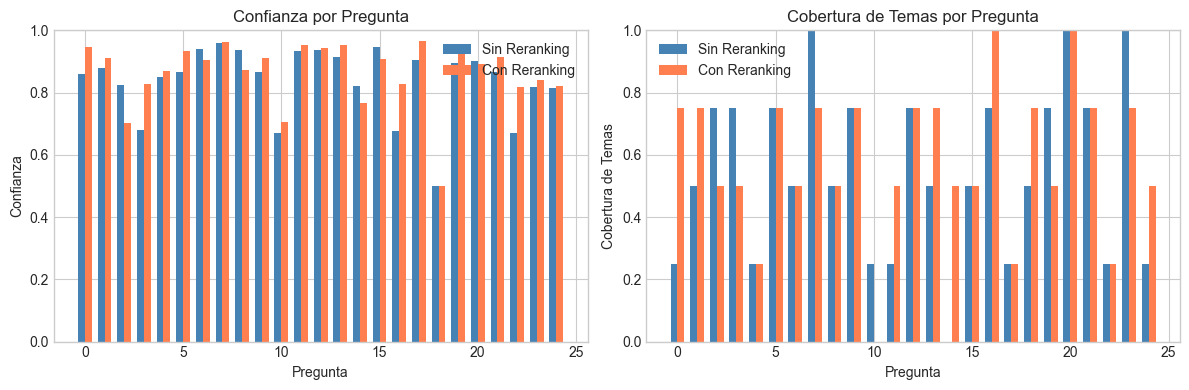

In [14]:
# Visualización de comparación
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confianza
x = range(len(df_generation))
width = 0.35
axes[0].bar([i - width/2 for i in x], df_generation['confidence'], width, label='Sin Reranking', color='steelblue')
axes[0].bar([i + width/2 for i in x], df_generation_rerank['confidence'], width, label='Con Reranking', color='coral')
axes[0].set_xlabel('Pregunta')
axes[0].set_ylabel('Confianza')
axes[0].set_title('Confianza por Pregunta')
axes[0].legend()
axes[0].set_ylim(0, 1)

# Topic Coverage
axes[1].bar([i - width/2 for i in x], df_generation['topic_coverage'], width, label='Sin Reranking', color='steelblue')
axes[1].bar([i + width/2 for i in x], df_generation_rerank['topic_coverage'], width, label='Con Reranking', color='coral')
axes[1].set_xlabel('Pregunta')
axes[1].set_ylabel('Cobertura de Temas')
axes[1].set_title('Cobertura de Temas por Pregunta')
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../docs/images/reranking_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Evaluación de Faithfulness (LLM-as-Judge)

Faithfulness mide si la respuesta generada está basada fielmente en los documentos recuperados (no alucina).

In [18]:
import re

def evaluate_faithfulness(question: str, answer: str, articles: list) -> dict:
    """
    Evalúa si la respuesta es fiel a las fuentes (no alucina).
    Usa LLM-as-Judge para evaluar.
    
    Args:
        question: La pregunta original
        answer: La respuesta generada
        articles: Lista de tuplas (Article, score) con contenido completo
    """
    llm = get_available_client()
    if not llm:
        return {"faithfulness_score": None, "explanation": "No LLM available"}
    
    # Incluir contenido de los artículos, no solo títulos
    sources_text = ""
    for i, (article, score) in enumerate(articles):
        content = article.content or article.description or ""
        content_preview = content[:500] + "..." if len(content) > 500 else content
        sources_text += f"\n[{i+1}] {article.title}\n"
        sources_text += f"    Fuente: {article.source_name}\n"
        sources_text += f"    Contenido: {content_preview}\n"
    
    prompt = f"""Evalúa si la siguiente respuesta está basada fielmente en las fuentes proporcionadas.

PREGUNTA: {question}

FUENTES:
{sources_text}

RESPUESTA: {answer}

Evalúa del 1 al 10:
- 10: Completamente fiel, todo está en las fuentes
- 5: Parcialmente fiel, algunas cosas no están en las fuentes
- 1: No es fiel, hay información inventada

Responde SOLO con el número (1-10):"""

    try:
        response = llm.generate(prompt, max_tokens=150, temperature=0)
        raw_response = response.content.strip()
        
        print(f"  LLM response: '{raw_response}'")
        
        numbers = re.findall(r'\b(\d+)\b', raw_response)
        if numbers:
            score = min(int(numbers[0]), 10) / 10.0
            print(f"  Score extraído: {score:.0%}")
            return {"faithfulness_score": score}
        else:
            print(f"  No se encontró número en la respuesta")
            return {"faithfulness_score": None}
            
    except Exception as e:
        print(f"  Error: {e}")
        return {"faithfulness_score": None}

print("✓ Función evaluate_faithfulness definida (con contenido de artículos)")

✓ Función evaluate_faithfulness definida (con contenido de artículos)


In [19]:
# Evaluar faithfulness para las respuestas generadas por LM Studio
# Ahora usando contenido completo de los artículos (no solo títulos)
faithfulness_scores = []

for i, result in enumerate(generation_results):
    print(f"Evaluando faithfulness {i+1}/{len(generation_results)}...")
    
    with get_db() as db:
        engine = RAGEngine(db, use_reranking=False)
        # Obtener artículos CON CONTENIDO
        articles = engine.get_context_only(
            question=EVALUATION_QUESTIONS[i]['question'],
            max_sources=5
        )
        
        faith_result = evaluate_faithfulness(
            question=EVALUATION_QUESTIONS[i]['question'],
            answer=result['answer'],
            articles=articles,
        )
        faithfulness_scores.append(faith_result['faithfulness_score'])

df_generation['faithfulness'] = faithfulness_scores
print(f"\n{'='*50}")
print(f"Faithfulness LM Studio promedio: {df_generation['faithfulness'].mean():.2%}")

Evaluando faithfulness 1/25...
2026-02-07 19:22:08 [info     ] Using LM Studio (local)       
2026-02-07 19:22:08 [info     ] Initialized LMStudioEmbeddingGenerator base_url=http://192.168.68.54:1234/v1 model=text-embedding-nomic-embed-text-v1.5
2026-02-07 19:22:08 [info     ] RAG engine initialized         llm_available=True use_reranking=False
2026-02-07 19:22:08 [info     ] Searching for articles         limit=5 query=¿Qué está pasando con la economía? threshold=0.5
2026-02-07 19:22:10 [info     ] Search completed               results_count=5
2026-02-07 19:22:10 [info     ] Using LM Studio (local)       
  LLM response: '5'
  Score extraído: 50%
Evaluando faithfulness 2/25...
2026-02-07 19:22:28 [info     ] Using LM Studio (local)       
2026-02-07 19:22:28 [info     ] Initialized LMStudioEmbeddingGenerator base_url=http://192.168.68.54:1234/v1 model=text-embedding-nomic-embed-text-v1.5
2026-02-07 19:22:28 [info     ] RAG engine initialized         llm_available=True use_reranking=

### 6.1 Comparación de Evaluadores: LM Studio vs DeepSeek

Comparamos cómo evalúan faithfulness ambos modelos para ver si son consistentes.

In [20]:
# Función para evaluar faithfulness con un proveedor específico
from src.llm.factory import get_llm_client
from src.config.settings import LLMProvider, settings

def evaluate_faithfulness_with_provider(
    question: str, 
    answer: str, 
    articles: list,
    provider: LLMProvider
) -> dict:
    """
    Evalúa faithfulness usando un proveedor LLM específico.
    
    Args:
        question: La pregunta original
        answer: La respuesta generada
        articles: Lista de tuplas (Article, score) con contenido completo
        provider: Proveedor LLM a usar como juez
    """
    try:
        llm = get_llm_client(provider)
    except Exception as e:
        print(f"  Error inicializando {provider}: {e}")
        return {"faithfulness_score": None, "provider": provider.value}
    
    # Incluir contenido de los artículos, no solo títulos
    sources_text = ""
    for i, (article, score) in enumerate(articles):
        content = article.content or article.description or ""
        content_preview = content[:500] + "..." if len(content) > 500 else content
        sources_text += f"\n[{i+1}] {article.title}\n"
        sources_text += f"    Fuente: {article.source_name}\n"
        sources_text += f"    Contenido: {content_preview}\n"
    
    prompt = f"""Evalúa si la siguiente respuesta está basada fielmente en las fuentes proporcionadas.

PREGUNTA: {question}

FUENTES:
{sources_text}

RESPUESTA: {answer}

Evalúa del 1 al 10:
- 10: Completamente fiel, todo está en las fuentes
- 5: Parcialmente fiel, algunas cosas no están en las fuentes
- 1: No es fiel, hay información inventada

Responde SOLO con el número (1-10):"""

    try:
        response = llm.generate(prompt, max_tokens=150, temperature=0)
        raw_response = response.content.strip()
        
        print(f"  [{provider.value}] Response: '{raw_response}'")
        
        numbers = re.findall(r'\b(\d+)\b', raw_response)
        if numbers:
            score = min(int(numbers[0]), 10) / 10.0
            return {"faithfulness_score": score, "provider": provider.value}
        else:
            return {"faithfulness_score": None, "provider": provider.value}
            
    except Exception as e:
        print(f"  [{provider.value}] Error: {e}")
        return {"faithfulness_score": None, "provider": provider.value}

# Verificar configuración
print("Configuración:")
print(f"  DeepSeek API Key: {'✓ Configurado' if settings.deepseek_api_key else '✗ NO CONFIGURADO'}")
print("\n✓ Función evaluate_faithfulness_with_provider definida (con contenido de artículos)")

Configuración:
  DeepSeek API Key: ✓ Configurado

✓ Función evaluate_faithfulness_with_provider definida (con contenido de artículos)


In [21]:
# Comparar evaluadores: LM Studio vs DeepSeek
# Evaluamos las MISMAS respuestas (generadas por LM Studio) con ambos evaluadores
# Ahora usando contenido completo de los artículos

comparison_results = []

for i, result in enumerate(generation_results):
    question = EVALUATION_QUESTIONS[i]['question']
    print(f"\n{'='*50}")
    print(f"Pregunta {i+1}: {question[:40]}...")
    
    with get_db() as db:
        engine = RAGEngine(db, use_reranking=False)
        # Obtener artículos CON CONTENIDO
        articles = engine.get_context_only(
            question=question,
            max_sources=5
        )
        
        # Evaluar con LM Studio
        print("Evaluando con LM Studio...")
        lm_result = evaluate_faithfulness_with_provider(
            question, result['answer'], articles, LLMProvider.LM_STUDIO
        )
        
        # Evaluar con DeepSeek (si está configurado)
        ds_result = {"faithfulness_score": None, "provider": "deepseek"}
        if settings.deepseek_api_key:
            print("Evaluando con DeepSeek...")
            ds_result = evaluate_faithfulness_with_provider(
                question, result['answer'], articles, LLMProvider.DEEPSEEK
            )
        
        comparison_results.append({
            "question": question,
            "lm_studio_score": lm_result['faithfulness_score'],
            "deepseek_score": ds_result['faithfulness_score'],
        })

# Mostrar resultados
df_comparison = pd.DataFrame(comparison_results)
print("\n" + "="*60)
print("COMPARACIÓN DE EVALUADORES DE FAITHFULNESS")
print("="*60)
print(df_comparison.to_string(index=False))

# Resumen
lm_scores = [r['lm_studio_score'] for r in comparison_results if r['lm_studio_score'] is not None]
ds_scores = [r['deepseek_score'] for r in comparison_results if r['deepseek_score'] is not None]

print(f"\nLM Studio promedio:  {np.mean(lm_scores):.1%}" if lm_scores else "\nLM Studio: No data")
print(f"DeepSeek promedio:   {np.mean(ds_scores):.1%}" if ds_scores else "DeepSeek: No configurado")


Pregunta 1: ¿Qué está pasando con la economía?...
2026-02-07 19:30:22 [info     ] Using LM Studio (local)       
2026-02-07 19:30:22 [info     ] Initialized LMStudioEmbeddingGenerator base_url=http://192.168.68.54:1234/v1 model=text-embedding-nomic-embed-text-v1.5
2026-02-07 19:30:22 [info     ] RAG engine initialized         llm_available=True use_reranking=False
2026-02-07 19:30:22 [info     ] Searching for articles         limit=5 query=¿Qué está pasando con la economía? threshold=0.5
2026-02-07 19:30:24 [info     ] Search completed               results_count=5
Evaluando con LM Studio...
2026-02-07 19:30:24 [info     ] Initializing LM Studio client  model=openai/gpt-oss-20b
  [lm_studio] Response: '5'
Evaluando con DeepSeek...
2026-02-07 19:30:41 [info     ] Initializing DeepSeek client   model=deepseek-chat
  [deepseek] Response: '5'

Pregunta 2: ¿Cuáles son las perspectivas económicas ...
2026-02-07 19:30:43 [info     ] Using LM Studio (local)       
2026-02-07 19:30:44 [info   

### 6.2 Comparación de Generación RAG: LM Studio vs DeepSeek

Ahora comparamos las **respuestas RAG generadas** por cada modelo para ver cuál produce menos alucinaciones.

In [22]:
# Comparar generación RAG con diferentes modelos
# Esta celda genera respuestas RAG usando DeepSeek y las evalúa
import re

if not settings.deepseek_api_key:
    print("⚠️ DeepSeek no configurado. Salta esta celda.")
else:
    deepseek_generation_results = []
    
    for q in EVALUATION_QUESTIONS:
        print(f"\nGenerando con DeepSeek: {q['question'][:40]}...")
        
        with get_db() as db:
            # Crear RAG Engine con DeepSeek
            deepseek_client = get_llm_client(LLMProvider.DEEPSEEK)
            engine = RAGEngine(db, llm_client=deepseek_client, use_reranking=False)
            
            response = engine.ask(
                question=q["question"],
                max_sources=5,
            )
            
            # Métricas
            citations = len(re.findall(r'\[\d+\]', response.answer))
            answer_lower = response.answer.lower()
            topics_found = [t for t in q["expected_topics"] if t.lower() in answer_lower]
            
            deepseek_generation_results.append({
                "question": q["question"],
                "answer": response.answer,
                "sources_used": len(response.sources),
                "citations": citations,
                "confidence": response.confidence,
                "topic_coverage": len(topics_found) / len(q["expected_topics"]),
            })
            
            print(f"  Confianza: {response.confidence:.1%}, Fuentes: {len(response.sources)}")
    
    df_deepseek_gen = pd.DataFrame(deepseek_generation_results)
    print("\n" + "="*50)
    print("GENERACIÓN CON DEEPSEEK")
    print("="*50)
    print(df_deepseek_gen[['question', 'sources_used', 'citations', 'confidence', 'topic_coverage']].to_string(index=False))


Generando con DeepSeek: ¿Qué está pasando con la economía?...
2026-02-07 19:40:31 [info     ] Initializing DeepSeek client   model=deepseek-chat
2026-02-07 19:40:31 [info     ] Initialized LMStudioEmbeddingGenerator base_url=http://192.168.68.54:1234/v1 model=text-embedding-nomic-embed-text-v1.5
2026-02-07 19:40:31 [info     ] RAG engine initialized         llm_available=True use_reranking=False
2026-02-07 19:40:31 [info     ] Processing RAG query           category=None max_sources=5 question=¿Qué está pasando con la economía?
2026-02-07 19:40:31 [info     ] Searching for articles         limit=5 query=¿Qué está pasando con la economía? threshold=0.5
2026-02-07 19:40:33 [info     ] Search completed               results_count=5
2026-02-07 19:40:33 [info     ] Generating RAG response        articles=5 query=¿Qué está pasando con la economía?
2026-02-07 19:40:41 [info     ] RAG response generated         answer_length=1128 confidence=0.8605775974337163 sources_used=3
2026-02-07 19:40:4

In [23]:
# Evaluar faithfulness de respuestas generadas por DeepSeek
# Usamos DeepSeek también como evaluador para consistencia
# Ahora pasando contenido completo de los artículos

if settings.deepseek_api_key and 'deepseek_generation_results' in dir():
    deepseek_faithfulness = []
    
    for i, result in enumerate(deepseek_generation_results):
        print(f"\nEvaluando faithfulness DeepSeek→DeepSeek {i+1}/{len(deepseek_generation_results)}...")
        
        with get_db() as db:
            engine = RAGEngine(db, use_reranking=False)
            # Obtener artículos CON CONTENIDO
            articles = engine.get_context_only(
                question=EVALUATION_QUESTIONS[i]['question'],
                max_sources=5
            )
            
            faith_result = evaluate_faithfulness_with_provider(
                EVALUATION_QUESTIONS[i]['question'],
                result['answer'],
                articles,
                LLMProvider.DEEPSEEK
            )
            deepseek_faithfulness.append(faith_result['faithfulness_score'])
    
    df_deepseek_gen['faithfulness'] = deepseek_faithfulness
    
    # Comparación final
    print("\n" + "="*60)
    print("COMPARACIÓN FINAL: GENERACIÓN RAG")
    print("="*60)
    
    lm_conf = f"{df_generation['confidence'].mean():.1%}"
    ds_conf = f"{df_deepseek_gen['confidence'].mean():.1%}"
    lm_topic = f"{df_generation['topic_coverage'].mean():.1%}"
    ds_topic = f"{df_deepseek_gen['topic_coverage'].mean():.1%}"
    lm_citas = f"{df_generation['citations_in_answer'].mean():.1f}"
    ds_citas = f"{df_deepseek_gen['citations'].mean():.1f}"
    
    lm_faith = df_generation['faithfulness'].mean() if 'faithfulness' in df_generation.columns else 0
    ds_faith = df_deepseek_gen['faithfulness'].mean() if deepseek_faithfulness else 0
    lm_faith_str = f"{lm_faith:.1%}" if lm_faith else "N/A"
    ds_faith_str = f"{ds_faith:.1%}" if ds_faith else "N/A"
    
    print(f"\n{'Métrica':<25} {'LM Studio':<15} {'DeepSeek':<15}")
    print("-"*55)
    print(f"{'Confianza promedio':<25} {lm_conf:<15} {ds_conf:<15}")
    print(f"{'Cobertura temas':<25} {lm_topic:<15} {ds_topic:<15}")
    print(f"{'Citas usadas':<25} {lm_citas:<15} {ds_citas:<15}")
    print(f"{'Faithfulness':<25} {lm_faith_str:<15} {ds_faith_str:<15}")
    
    print("\n" + "="*60)
    if ds_faith and lm_faith and ds_faith > lm_faith + 0.1:
        print("✓ DeepSeek genera respuestas más fieles a las fuentes")
    elif ds_faith and lm_faith and lm_faith > ds_faith + 0.1:
        print("✓ LM Studio genera respuestas más fieles a las fuentes")
    else:
        print("≈ Ambos modelos tienen faithfulness similar")
else:
    print("⚠️ Ejecuta primero la celda de generación con DeepSeek")


Evaluando faithfulness DeepSeek→DeepSeek 1/25...
2026-02-07 19:44:14 [info     ] Using LM Studio (local)       
2026-02-07 19:44:14 [info     ] Initialized LMStudioEmbeddingGenerator base_url=http://192.168.68.54:1234/v1 model=text-embedding-nomic-embed-text-v1.5
2026-02-07 19:44:14 [info     ] RAG engine initialized         llm_available=True use_reranking=False
2026-02-07 19:44:14 [info     ] Searching for articles         limit=5 query=¿Qué está pasando con la economía? threshold=0.5
2026-02-07 19:44:14 [info     ] Search completed               results_count=5
2026-02-07 19:44:14 [info     ] Initializing DeepSeek client   model=deepseek-chat
  [deepseek] Response: '5'

Evaluando faithfulness DeepSeek→DeepSeek 2/25...
2026-02-07 19:44:15 [info     ] Using LM Studio (local)       
2026-02-07 19:44:15 [info     ] Initialized LMStudioEmbeddingGenerator base_url=http://192.168.68.54:1234/v1 model=text-embedding-nomic-embed-text-v1.5
2026-02-07 19:44:15 [info     ] RAG engine initialize

### 6.3 Fact-Checking: Verificación por Claims

Implementamos una evaluación más rigurosa siguiendo las recomendaciones de Gilhuly y Shahzad (2025):

1. **Descomponer** la respuesta en afirmaciones individuales (claims)
2. **Verificar** cada claim contra las fuentes originales
3. **Calcular** la tasa de alucinación (claims sin respaldo)

In [24]:
# Funciones de Fact-Checking (MEJORADAS)

def extract_claims(answer: str, llm_client=None) -> list[str]:
    """
    Descompone una respuesta en afirmaciones factuales individuales.
    """
    if llm_client is None:
        llm_client = get_available_client()
    
    prompt = """Extrae SOLO las afirmaciones factuales PRINCIPALES del siguiente texto.
NO extraigas detalles menores o inferencias. Solo hechos concretos y verificables.
Devuelve UNA afirmación por línea, sin números ni viñetas.
Máximo 5-7 afirmaciones principales.

TEXTO:
{text}

AFIRMACIONES PRINCIPALES (una por línea):"""
    
    try:
        response = llm_client.generate(prompt.format(text=answer), max_tokens=500, temperature=0)
        claims = [line.strip() for line in response.content.strip().split('\n') if line.strip()]
        # Filtrar líneas que no parecen claims (muy cortas o son headers)
        claims = [c for c in claims if len(c) > 20 and not c.endswith(':')]
        return claims[:7]  # Máximo 7 claims
    except Exception as e:
        print(f"  Error extrayendo claims: {e}")
        return []


def verify_claim(claim: str, sources_text: str, llm_client=None) -> dict:
    """
    Verifica si un claim está respaldado por las fuentes.
    IMPORTANTE: sources_text debe incluir el CONTENIDO de los artículos.
    """
    if llm_client is None:
        llm_client = get_available_client()
    
    prompt = """Determina si la siguiente AFIRMACIÓN está respaldada por la información en las FUENTES.

AFIRMACIÓN: {claim}

FUENTES (títulos y contenido):
{sources}

Instrucciones:
- RESPALDADO: La información está claramente en las fuentes (puede ser parafraseada)
- PARCIAL: La idea general está en las fuentes pero faltan detalles específicos
- NO RESPALDADO: La información NO aparece en las fuentes

Tu respuesta (una sola palabra - RESPALDADO, PARCIAL, o NO RESPALDADO):"""
    
    try:
        response = llm_client.generate(
            prompt.format(claim=claim, sources=sources_text), 
            max_tokens=50, 
            temperature=0
        )
        result = response.content.strip().upper()
        
        if 'RESPALDADO' in result and 'NO' not in result:
            return {'supported': True, 'status': 'RESPALDADO'}
        elif 'PARCIAL' in result:
            return {'supported': True, 'status': 'PARCIAL'}  # Contamos parcial como OK
        else:
            return {'supported': False, 'status': 'NO RESPALDADO'}
    except Exception as e:
        print(f"  Error verificando claim: {e}")
        return {'supported': False, 'status': 'ERROR'}


def fact_check_answer(question: str, answer: str, articles: list, llm_client=None) -> dict:
    """
    Realiza fact-checking completo de una respuesta.
    
    Args:
        question: La pregunta original
        answer: La respuesta generada
        articles: Lista de tuplas (Article, score) con el contenido completo
        llm_client: Cliente LLM para evaluación
    
    Returns:
        dict con claims, verificaciones y tasa de alucinación
    """
    if llm_client is None:
        llm_client = get_available_client()
    
    # 1. Extraer claims (máximo 7)
    claims = extract_claims(answer, llm_client)
    
    if not claims:
        return {
            'total_claims': 0,
            'supported_claims': 0,
            'hallucination_rate': None,
            'claims_detail': []
        }
    
    # 2. Preparar texto de fuentes CON CONTENIDO
    sources_text = ""
    for i, (article, score) in enumerate(articles):
        # Incluir título + descripción/contenido (primeros 500 chars)
        content = article.content or article.description or ""
        content_preview = content[:500] + "..." if len(content) > 500 else content
        sources_text += f"\n[{i+1}] {article.title}\n"
        sources_text += f"    Fuente: {article.source_name}\n"
        sources_text += f"    Contenido: {content_preview}\n"
    
    # 3. Verificar cada claim
    claims_detail = []
    supported_count = 0
    
    for claim in claims:
        result = verify_claim(claim, sources_text, llm_client)
        claims_detail.append({
            'claim': claim,
            'supported': result['supported'],
            'status': result['status']
        })
        if result['supported']:
            supported_count += 1
    
    # 4. Calcular tasa de alucinación
    hallucination_rate = 1 - (supported_count / len(claims))
    
    return {
        'total_claims': len(claims),
        'supported_claims': supported_count,
        'unsupported_claims': len(claims) - supported_count,
        'hallucination_rate': hallucination_rate,
        'claims_detail': claims_detail
    }

print("Funciones de fact-checking definidas")

Funciones de fact-checking definidas


In [25]:
# Ejecutar Fact-Checking MEJORADO con DeepSeek
# Ahora pasamos el CONTENIDO de los artículos, no solo los títulos

if not settings.deepseek_api_key:
    print("⚠️ DeepSeek no configurado. Usando LM Studio.")
    fact_check_llm = get_available_client()
else:
    fact_check_llm = get_llm_client(LLMProvider.DEEPSEEK)
    print("✓ Usando DeepSeek para fact-checking")

fact_check_results = []

# Usar las respuestas de DeepSeek (o LM Studio si no hay)
responses_to_check = deepseek_generation_results if 'deepseek_generation_results' in dir() else generation_results
print(f"✓ Verificando respuestas de: {'DeepSeek' if 'deepseek_generation_results' in dir() else 'LM Studio'}")
print(f"✓ Total preguntas a evaluar: {len(responses_to_check)}")

for i, result in enumerate(responses_to_check):
    question = EVALUATION_QUESTIONS[i]['question']
    print(f"\n{'='*60}")
    print(f"[{i+1}/{len(responses_to_check)}] Fact-checking: {question[:50]}...")
    
    with get_db() as db:
        engine = RAGEngine(db, use_reranking=False)
        # Obtener artículos CON CONTENIDO (no solo SourceCitation)
        articles = engine.get_context_only(question=question, max_sources=5)
        
        # Fact-check pasando los artículos completos
        fc_result = fact_check_answer(
            question=question,
            answer=result['answer'],
            articles=articles,  # Ahora son tuplas (Article, score) con contenido
            llm_client=fact_check_llm
        )
        
        fact_check_results.append({
            'question': question,
            **fc_result
        })
        
        print(f"  Claims totales: {fc_result['total_claims']}")
        print(f"  Respaldados: {fc_result['supported_claims']}")
        print(f"  Sin respaldo: {fc_result['unsupported_claims']}")
        if fc_result['hallucination_rate'] is not None:
            print(f"  Tasa alucinación: {fc_result['hallucination_rate']:.1%}")

# Crear DataFrame
df_factcheck = pd.DataFrame(fact_check_results)
print("\n" + "="*60)
print("RESUMEN FACT-CHECKING (CON CONTENIDO DE ARTÍCULOS)")
print("="*60)
print(df_factcheck[['question', 'total_claims', 'supported_claims', 'unsupported_claims', 'hallucination_rate']].to_string(index=False))

2026-02-07 19:45:52 [info     ] Initializing DeepSeek client   model=deepseek-chat
✓ Usando DeepSeek para fact-checking
✓ Verificando respuestas de: DeepSeek
✓ Total preguntas a evaluar: 25

[1/25] Fact-checking: ¿Qué está pasando con la economía?...
2026-02-07 19:45:52 [info     ] Using LM Studio (local)       
2026-02-07 19:45:52 [info     ] Initialized LMStudioEmbeddingGenerator base_url=http://192.168.68.54:1234/v1 model=text-embedding-nomic-embed-text-v1.5
2026-02-07 19:45:52 [info     ] RAG engine initialized         llm_available=True use_reranking=False
2026-02-07 19:45:52 [info     ] Searching for articles         limit=5 query=¿Qué está pasando con la economía? threshold=0.5
2026-02-07 19:45:52 [info     ] Search completed               results_count=5
  Claims totales: 5
  Respaldados: 3
  Sin respaldo: 2
  Tasa alucinación: 40.0%

[2/25] Fact-checking: ¿Cuáles son las perspectivas económicas para 2026?...
2026-02-07 19:46:03 [info     ] Using LM Studio (local)       
2026-0

ANÁLISIS DE FACT-CHECKING

Muestra evaluada: 25 respuestas
Total claims analizados: 135
Claims promedio por respuesta: 5.4

Claims respaldados: 102 (75.6%)
Claims sin respaldo: 33 (24.4%)

TASA DE ALUCINACIÓN PROMEDIO: 24.3%

✓ Bueno: Entre 10-25% de alucinación


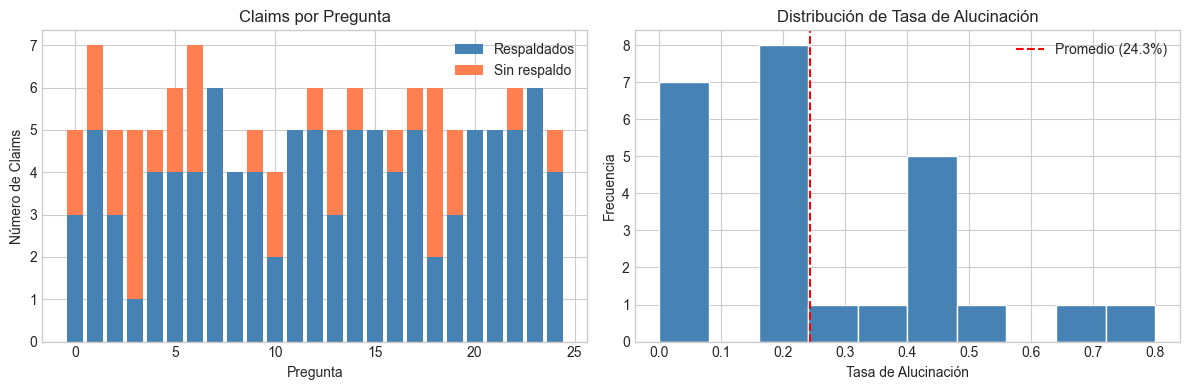

In [26]:
# Análisis de Fact-Checking
if len(df_factcheck) > 0 and df_factcheck['hallucination_rate'].notna().any():
    avg_hallucination = df_factcheck['hallucination_rate'].mean()
    avg_claims = df_factcheck['total_claims'].mean()
    total_claims = df_factcheck['total_claims'].sum()
    total_supported = df_factcheck['supported_claims'].sum()
    
    print("=" * 60)
    print("ANÁLISIS DE FACT-CHECKING")
    print("=" * 60)
    print(f"\nMuestra evaluada: {len(df_factcheck)} respuestas")
    print(f"Total claims analizados: {total_claims}")
    print(f"Claims promedio por respuesta: {avg_claims:.1f}")
    print()
    print(f"Claims respaldados: {total_supported} ({total_supported/total_claims:.1%})")
    print(f"Claims sin respaldo: {total_claims - total_supported} ({(total_claims - total_supported)/total_claims:.1%})")
    print()
    print(f"{'='*40}")
    print(f"TASA DE ALUCINACIÓN PROMEDIO: {avg_hallucination:.1%}")
    print(f"{'='*40}")
    print()
    
    # Interpretación
    if avg_hallucination < 0.1:
        print("✅ Excelente: Menos del 10% de alucinación")
    elif avg_hallucination < 0.25:
        print("✓ Bueno: Entre 10-25% de alucinación")
    elif avg_hallucination < 0.40:
        print("⚠️ Moderado: Entre 25-40% de alucinación")
    else:
        print("❌ Alto: Más del 40% de alucinación - requiere mejoras")
    
    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Gráfico de barras por pregunta
    x = range(len(df_factcheck))
    axes[0].bar(x, df_factcheck['supported_claims'], label='Respaldados', color='steelblue')
    axes[0].bar(x, df_factcheck['unsupported_claims'], bottom=df_factcheck['supported_claims'], 
                label='Sin respaldo', color='coral')
    axes[0].set_xlabel('Pregunta')
    axes[0].set_ylabel('Número de Claims')
    axes[0].set_title('Claims por Pregunta')
    axes[0].legend()
    
    # Distribución de tasa de alucinación
    axes[1].hist(df_factcheck['hallucination_rate'].dropna(), bins=10, color='steelblue', edgecolor='white')
    axes[1].axvline(x=avg_hallucination, color='red', linestyle='--', label=f'Promedio ({avg_hallucination:.1%})')
    axes[1].set_xlabel('Tasa de Alucinación')
    axes[1].set_ylabel('Frecuencia')
    axes[1].set_title('Distribución de Tasa de Alucinación')
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig('../docs/images/factcheck_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ No hay datos de fact-checking para analizar")

## 7. Resumen Final

In [28]:
# Resumen final de todas las métricas
print("=" * 70)
print("RESUMEN DE EVALUACIÓN DEL SISTEMA RAG")
print("=" * 70)
print(f"\nDataset: {len(EVALUATION_QUESTIONS)} preguntas de prueba")
print(f"Base de datos: {total_articles} artículos")
print()

# Retrieval (independiente del LLM)
print("MÉTRICAS DE RETRIEVAL")
print("-" * 50)
print(f"  Precision@5:        {df_retrieval['precision_at_k'].mean():.2%}")
print(f"  Hit Rate:           {df_retrieval['hit_rate'].mean():.2%}")
print(f"  MRR:                {df_retrieval['mrr'].mean():.3f}")
print(f"  Avg Similarity:     {df_retrieval['avg_similarity'].mean():.3f}")
print()

# Generación - Comparación LM Studio vs DeepSeek
print("MÉTRICAS DE GENERACIÓN (LM Studio vs DeepSeek)")
print("-" * 50)
print(f"{'Métrica':<25} {'LM Studio':<15} {'DeepSeek':<15}")
print("-" * 50)

# Confianza
lm_conf = df_generation['confidence'].mean()
ds_conf = df_deepseek_gen['confidence'].mean() if 'df_deepseek_gen' in dir() else None
lm_conf_str = f"{lm_conf:.1%}"
ds_conf_str = f"{ds_conf:.1%}" if ds_conf else "N/A"
print(f"{'Confianza':<25} {lm_conf_str:<15} {ds_conf_str:<15}")

# Cobertura temas
lm_topic = df_generation['topic_coverage'].mean()
ds_topic = df_deepseek_gen['topic_coverage'].mean() if 'df_deepseek_gen' in dir() else None
lm_topic_str = f"{lm_topic:.1%}"
ds_topic_str = f"{ds_topic:.1%}" if ds_topic else "N/A"
print(f"{'Cobertura Temas':<25} {lm_topic_str:<15} {ds_topic_str:<15}")

# Citas usadas
lm_citas = df_generation['citations_in_answer'].mean()
ds_citas = df_deepseek_gen['citations'].mean() if 'df_deepseek_gen' in dir() else None
lm_citas_str = f"{lm_citas:.1f}"
ds_citas_str = f"{ds_citas:.1f}" if ds_citas else "N/A"
print(f"{'Citas Usadas':<25} {lm_citas_str:<15} {ds_citas_str:<15}")

# Faithfulness (LLM-as-Judge)
lm_faith = df_generation['faithfulness'].mean() if df_generation['faithfulness'].notna().any() else None
ds_faith = df_deepseek_gen['faithfulness'].mean() if 'df_deepseek_gen' in dir() and 'faithfulness' in df_deepseek_gen.columns else None
lm_faith_str = f"{lm_faith:.1%}" if lm_faith else "N/A"
ds_faith_str = f"{ds_faith:.1%}" if ds_faith else "N/A"
print(f"{'Faithfulness (Judge)':<25} {lm_faith_str:<15} {ds_faith_str:<15}")

print()
print("COMPARACIÓN RERANKING (LM Studio)")
print("-" * 50)
print(f"  Sin Reranking:      {df_generation['confidence'].mean():.2%} confianza")
print(f"  Con Reranking:      {df_generation_rerank['confidence'].mean():.2%} confianza")
print(f"  Mejora:             +{(df_generation_rerank['confidence'].mean() - df_generation['confidence'].mean()):.2%}")

# Fact-Checking (si está disponible)
if 'df_factcheck' in dir() and len(df_factcheck) > 0 and df_factcheck['hallucination_rate'].notna().any():
    print()
    print("FACT-CHECKING (Verificación por Claims)")
    print("-" * 50)
    avg_hallucination = df_factcheck['hallucination_rate'].mean()
    total_claims = df_factcheck['total_claims'].sum()
    total_supported = df_factcheck['supported_claims'].sum()
    print(f"  Muestra evaluada:   {len(df_factcheck)} respuestas")
    print(f"  Total claims:       {total_claims}")
    print(f"  Claims respaldados: {total_supported} ({total_supported/total_claims:.1%})")
    print(f"  Tasa alucinación:   {avg_hallucination:.1%}")

print()
print("=" * 70)
# Conclusión
if ds_faith and lm_faith:
    if ds_faith > lm_faith + 0.1:
        print("✓ DeepSeek genera respuestas más fieles a las fuentes")
        print(f"  (Faithfulness: {ds_faith:.1%} vs {lm_faith:.1%}, diferencia de {ds_faith - lm_faith:.1%})")
    elif lm_faith > ds_faith + 0.1:
        print("✓ LM Studio genera respuestas más fieles a las fuentes")
    else:
        print("≈ Ambos modelos tienen faithfulness similar")
print("=" * 70)

RESUMEN DE EVALUACIÓN DEL SISTEMA RAG

Dataset: 25 preguntas de prueba
Base de datos: 1688 artículos

MÉTRICAS DE RETRIEVAL
--------------------------------------------------
  Precision@5:        100.00%
  Hit Rate:           100.00%
  MRR:                1.000
  Avg Similarity:     0.702

MÉTRICAS DE GENERACIÓN (LM Studio vs DeepSeek)
--------------------------------------------------
Métrica                   LM Studio       DeepSeek       
--------------------------------------------------
Confianza                 83.7%           85.8%          
Cobertura Temas           55.0%           61.0%          
Citas Usadas              3.0             4.1            
Faithfulness (Judge)      77.9%           75.6%          

COMPARACIÓN RERANKING (LM Studio)
--------------------------------------------------
  Sin Reranking:      83.71% confianza
  Con Reranking:      86.43% confianza
  Mejora:             +2.72%

FACT-CHECKING (Verificación por Claims)
-----------------------------------

In [29]:
# Guardar resultados para el TFM
results_summary = {
    'timestamp': datetime.now().isoformat(),
    'dataset_size': len(EVALUATION_QUESTIONS),
    'db_articles': total_articles,
    'retrieval': {
        'precision_at_5': float(df_retrieval['precision_at_k'].mean()),
        'hit_rate': float(df_retrieval['hit_rate'].mean()),
        'mrr': float(df_retrieval['mrr'].mean()),
        'avg_similarity': float(df_retrieval['avg_similarity'].mean()),
    },
    'generation': {
        'lm_studio': {
            'confidence': float(df_generation['confidence'].mean()),
            'topic_coverage': float(df_generation['topic_coverage'].mean()),
            'citations_used': float(df_generation['citations_in_answer'].mean()),
            'faithfulness': float(df_generation['faithfulness'].mean()) if df_generation['faithfulness'].notna().any() else None,
        },
        'deepseek': {
            'confidence': float(df_deepseek_gen['confidence'].mean()) if 'df_deepseek_gen' in dir() else None,
            'topic_coverage': float(df_deepseek_gen['topic_coverage'].mean()) if 'df_deepseek_gen' in dir() else None,
            'citations_used': float(df_deepseek_gen['citations'].mean()) if 'df_deepseek_gen' in dir() else None,
            'faithfulness': float(df_deepseek_gen['faithfulness'].mean()) if 'df_deepseek_gen' in dir() and 'faithfulness' in df_deepseek_gen.columns else None,
        } if 'df_deepseek_gen' in dir() else None,
    },
    'reranking_comparison': {
        'without': float(df_generation['confidence'].mean()),
        'with': float(df_generation_rerank['confidence'].mean()),
        'improvement': float(df_generation_rerank['confidence'].mean() - df_generation['confidence'].mean()),
    },
    'fact_checking': None
}

# Agregar fact-checking si está disponible
if 'df_factcheck' in dir() and len(df_factcheck) > 0 and df_factcheck['hallucination_rate'].notna().any():
    results_summary['fact_checking'] = {
        'sample_size': len(df_factcheck),
        'total_claims': int(df_factcheck['total_claims'].sum()),
        'supported_claims': int(df_factcheck['supported_claims'].sum()),
        'unsupported_claims': int(df_factcheck['total_claims'].sum() - df_factcheck['supported_claims'].sum()),
        'avg_hallucination_rate': float(df_factcheck['hallucination_rate'].mean()),
        'claims_per_response': float(df_factcheck['total_claims'].mean()),
    }

import json
with open('../docs/rag_evaluation_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2, default=str)

print("✓ Resultados guardados en docs/rag_evaluation_results.json")
print("\nContenido del archivo:")
print(json.dumps(results_summary, indent=2, default=str))

✓ Resultados guardados en docs/rag_evaluation_results.json

Contenido del archivo:
{
  "timestamp": "2026-02-07T19:55:38.825739",
  "dataset_size": 25,
  "db_articles": 1688,
  "retrieval": {
    "precision_at_5": 1.0,
    "hit_rate": 1.0,
    "mrr": 1.0,
    "avg_similarity": 0.7020484250318778
  },
  "generation": {
    "lm_studio": {
      "confidence": 0.8371483089000817,
      "topic_coverage": 0.55,
      "citations_used": 3.04,
      "faithfulness": 0.7791666666666667
    },
    "deepseek": {
      "confidence": 0.8584616161730261,
      "topic_coverage": 0.61,
      "citations_used": 4.08,
      "faithfulness": 0.7559999999999999
    }
  },
  "reranking_comparison": {
    "without": 0.8371483089000817,
    "with": 0.8643300108492386,
    "improvement": 0.02718170194915681
  },
  "fact_checking": {
    "sample_size": 25,
    "total_claims": 135,
    "supported_claims": 102,
    "unsupported_claims": 33,
    "avg_hallucination_rate": 0.24323809523809525,
    "claims_per_response"